<img src="Port Harcourt Fulfillment Risk & Retention Analytics.jpg" style="width:600px;">


<div style="background-color: cyan; padding: 10px; font-weight: bold;">
    Port Harcourt Fulfillment Risk & Retention Analytics.
</div>


<div style="background-color:#f0f8ff; padding:20px; border-radius:10px; font-family:Arial, sans-serif; line-height:1.6;">

  <p>
    The company has seen a <b>fast rise in sales</b> in the <b>Port Harcourt</b> region. But this sudden growth is also creating some serious problems. 
    Many popular products are often <b>out of stock</b>, and several orders are either getting <b>delayed</b> or <b>canceled</b>. 
    These issues are especially affecting <b>new customers</b> who joined after <b>March 2024</b>. 
    Because of these bad experiences, many of them are <b>not coming back to shop again</b>. 
    There are also doubts about some <b>suppliers</b> who might be responsible for poor product availability or delivery issues.
  </p>

  <h3>🎯 <b>Project Goals:</b></h3>
  <ul>
    <li><b>Find</b> which products are often out of stock or get canceled the most.</li>
    <li><b>Check</b> if new customers (after March 2024) are facing more delays or cancellations and if that’s stopping them from buying again.</li>
    <li><b>Identify</b> which suppliers are linked to these problems, especially for Port Harcourt deliveries.</li>
  </ul>

</div>


<div style="background-color: lightblue; padding: 10px; font-weight: bold;text-align: center;">
    Customer Dataset.
</div>

# Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<div style="background-color:#ccffeb; padding:10px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2><b>Exploratory Data Analysis (EDA)</b></h2>
</div>

# Loading the Dataset

In [2]:
df_1 = pd.read_csv("customers.csv")

In [3]:
df_1.head()   #Intial Data Inspection By Fetching Few Datas From Top

,CustomerID,FirstName,LastName,Email,Address,City,PostalCode,RegistrationDate,LastLoginDate,CustomerSegment,DateOfBirth,Phone
0,C00001,Chelsea,Macdonald,chelsea.macdonald@yahoo.com,53315 Wallace Spurs Apt. 571,Port Harcourt,695494.0,5/26/2024,NaN,VIP,2/26/1995,9074567463
1,C00002,Dean,Scott,dscott@outlook.com,"96030 Cruz Fords, Rivers",Port Harcourt,865924.0,12/21/2023,1/4/2025 18:51,standard,11/21/1983,8105943823
2,C00003,Sean,Brown,sean.brown@gmail.com,"2658 Montoya Vista, Lagos",Lagos,314272.0,12/2/2024,3/5/2025 17:49,standard,1/1/1900,9169283703
3,C00004,Kelly,Wright,kwright@yahoo.com,966 Thomas Square Suite 761,Kano,558844.0,2/12/2024,3/6/2025 3:43,Standard,3/28/1997,8265812270
4,C00005,Matthew,Jones,matthew.jones@iwantthis.com.ng,744 Hall Ranch,Abuja,863098.0,1/6/2024,8/31/2024 0:19,Silver,NaN,NaN


In [4]:
df_1.shape   #Shape of The Dataset

(15212, 12)

In [5]:
df_1.info()   #Basic Info About The Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15212 entries, 0 to 15211
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        15212 non-null  object 
 1   FirstName         15212 non-null  object 
 2   LastName          15212 non-null  object 
 3   Email             14902 non-null  object 
 4   Address           15212 non-null  object 
 5   City              15212 non-null  object 
 6   PostalCode        14470 non-null  float64
 7   RegistrationDate  15212 non-null  object 
 8   LastLoginDate     12076 non-null  object 
 9   CustomerSegment   13564 non-null  object 
 10  DateOfBirth       13303 non-null  object 
 11  Phone             14440 non-null  object 
dtypes: float64(1), object(11)
memory usage: 1.4+ MB


In [6]:
df_1.isnull().sum()   # Missing Values

CustomerID             0
FirstName              0
LastName               0
Email                310
Address                0
City                   0
PostalCode           742
RegistrationDate       0
LastLoginDate       3136
CustomerSegment     1648
DateOfBirth         1909
Phone                772
dtype: int64

<Axes: >

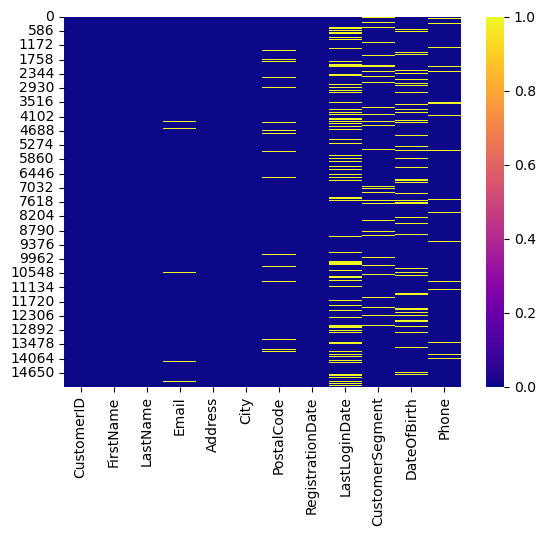

In [7]:
sns.heatmap(df_1.isnull(),cmap = 'plasma')   # Visualising Missing Values

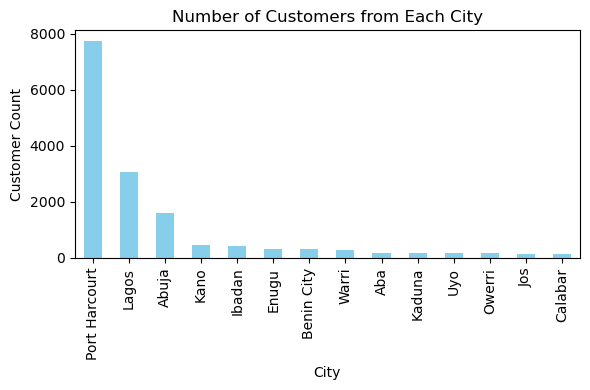

In [8]:
# Value counts of City
df_1['City'].value_counts().plot(kind='bar', figsize=(6,4), color='skyblue')


plt.title("Number of Customers from Each City")
plt.xlabel("City")
plt.ylabel("Customer Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:
df_1['CustomerSegment'].value_counts()

CustomerSegment
Bronze            1695
Standard          1645
Silver            1632
VIP               1610
Gold              1600
                  ... 
new                  8
Silver               8
Platinum (old)       7
NEW                  7
Gold_v2              7
Name: count, Length: 61, dtype: int64

In [10]:
#  Converted all to lowercase and removed extra spaces
df_1['CustomerSegment'] = df_1['CustomerSegment'].str.lower().str.strip()

# Replaced different versions with one standard label

df_1['CustomerSegment'] = df_1['CustomerSegment'].replace({
    'std.': 'standard',
    'standard (old)': 'standard',
    'standard_v2': 'standard',

    'vip (old)': 'vip',
    'vip_v2': 'vip',

    'gold (old)': 'gold',
    'gold_v2': 'gold',

    'silver (old)': 'silver',
    'silver_v2': 'silver',

    'platinum (old)': 'platinum',
    'platinum_v2': 'platinum',

    'bronze (old)': 'bronze',
    'bronze_v2': 'bronze',

    'new (old)': 'new',
    'new_v2': 'new',

    'regular': 'standard'  
})

# Counting members in each customer segment
print(df_1['CustomerSegment'].value_counts())


CustomerSegment
standard    3351
bronze      1800
silver      1720
vip         1708
gold        1692
platinum    1662
new         1631
Name: count, dtype: int64


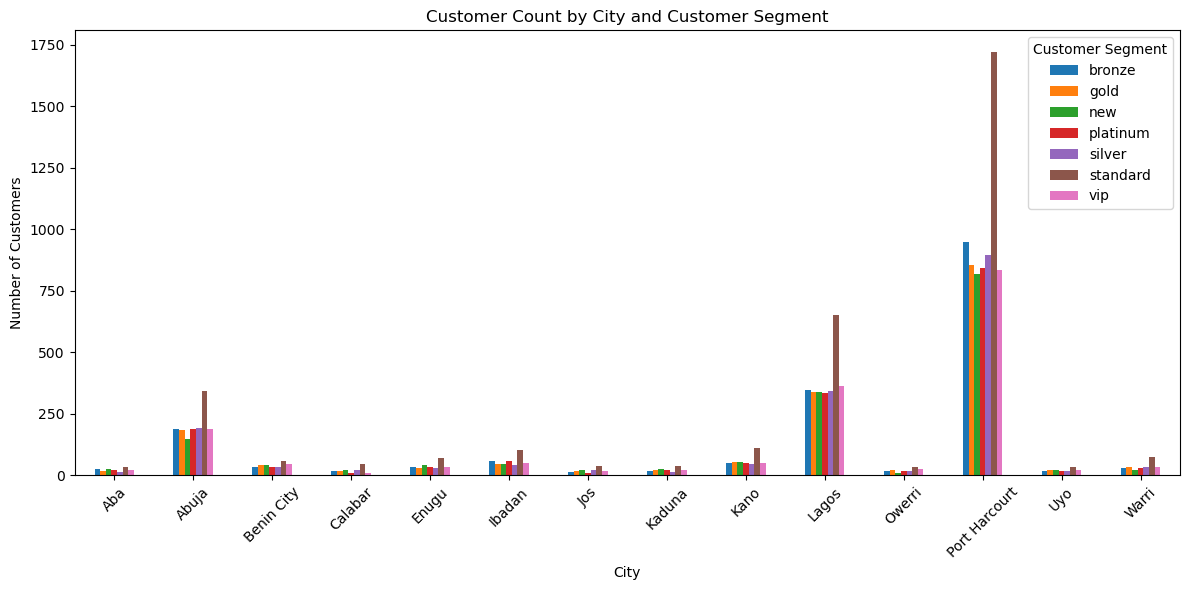

In [11]:
# Grouped and counted customers by City and CustomerSegment
counts = df_1.groupby(['City', 'CustomerSegment']).size().unstack(fill_value=0)

# Plot 
counts.plot(kind='bar', figsize=(12,6))  

plt.title('Customer Count by City and Customer Segment')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Customer Segment')
plt.tight_layout()
plt.show()


In [12]:
df_customer = df_1[['CustomerID', 'RegistrationDate','City']]

In [13]:
df_customer.head()

,CustomerID,RegistrationDate,City
0,C00001,5/26/2024,Port Harcourt
1,C00002,12/21/2023,Port Harcourt
2,C00003,12/2/2024,Lagos
3,C00004,2/12/2024,Kano
4,C00005,1/6/2024,Abuja


In [14]:
df_customer['RegistrationDate'] = pd.to_datetime(df_customer['RegistrationDate'], errors='coerce')

C:\Users\dell\AppData\Local\Temp\ipykernel_9768\1057666860.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['RegistrationDate'] = pd.to_datetime(df_customer['RegistrationDate'], errors='coerce')


In [15]:
df_customer.head()

,CustomerID,RegistrationDate,City
0,C00001,2024-05-26,Port Harcourt
1,C00002,2023-12-21,Port Harcourt
2,C00003,2024-12-02,Lagos
3,C00004,2024-02-12,Kano
4,C00005,2024-01-06,Abuja


In [82]:
df_customer.to_csv('Customer2.csv',index = False)   # This way u can save any file to csv format

# =============================================================

<div style="background-color: lightblue; padding: 10px; font-weight: bold;text-align: center;">
    Order_Items Dataset.
</div>

<div style="background-color:#ffd98f; padding:10px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2><b>Exploratory Data Analysis (EDA)</b></h2>
</div>

# Loading The Dataset

In [17]:
df_2 = pd.read_csv("order_items.csv")

In [18]:
df_2.shape

(163750, 7)

In [19]:
df_2.head()

,OrderItemID,OrderID,ProductID,Quantity,UnitPriceAtPurchase_NGN,TotalItemPrice_NGN,ReturnStatus
0,OI000001,ORD00001,P0001,2,2429.49,4858.98,NaN
1,OI000002,ORD00002,P0048,3,186953.78,560861.34,NaN
2,OI000003,ORD00003,P0001,1,2706.38,2706.38,NaN
3,OI000004,ORD00003,P0101,7,228767.53,1273235.37,Not Returned
4,OI000005,ORD00003,P0134,1,143004.19,143004.19,NaN


In [20]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163750 entries, 0 to 163749
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   OrderItemID              163750 non-null  object 
 1   OrderID                  163750 non-null  object 
 2   ProductID                163750 non-null  object 
 3   Quantity                 163750 non-null  int64  
 4   UnitPriceAtPurchase_NGN  163750 non-null  float64
 5   TotalItemPrice_NGN       162143 non-null  float64
 6   ReturnStatus             24645 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 8.7+ MB


In [21]:
df_2.isnull().sum()

OrderItemID                     0
OrderID                         0
ProductID                       0
Quantity                        0
UnitPriceAtPurchase_NGN         0
TotalItemPrice_NGN           1607
ReturnStatus               139105
dtype: int64

In [22]:
df_order_items = df_2[['OrderID', 'ProductID', 'Quantity', 'ReturnStatus']]

In [23]:
df_order_items.head()

,OrderID,ProductID,Quantity,ReturnStatus
0,ORD00001,P0001,2,NaN
1,ORD00002,P0048,3,NaN
2,ORD00003,P0001,1,NaN
3,ORD00003,P0101,7,Not Returned
4,ORD00003,P0134,1,NaN


In [24]:
df_order_items['ReturnStatus'].value_counts()

ReturnStatus
Not Returned    20548
Approved         1080
Completed        1043
Requested        1009
Rejected          965
Name: count, dtype: int64

In [80]:
df_order_items.to_csv('Order_items2.csv',index = False)  # This way u can save any file to csv format

# ============================================================

<div style="background-color: lightblue; padding: 10px; font-weight: bold;text-align: center;">
    Orders Dataset.
</div>

<div style="background-color:#FF66CC; padding:10px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2><b>Exploratory Data Analysis (EDA)</b></h2>
</div>

# Loading The Dataset

In [26]:
df_orders = pd.read_csv("orders.csv")

In [27]:
df_orders.shape

(75000, 19)

In [28]:
df_orders.head()

,OrderID,CustomerID,OrderDate,ShipDate,ExpectedDeliveryDate,ActualDeliveryDate,OrderStatus,ShippingMethod,ShippingCost_NGN,ShippingAddress,ShippingCity,ShippingState,ShippingPostalCode,ShippingCountry,PaymentMethod,PaymentStatus,DiscountCode,DiscountAmount_NGN,TotalAmount_NGN
0,ORD00001,C00167,2024-03-01 00:05:00,20240301120500,2024-03-02,20240302120500,Returned,Standard Delivery (NG),3524.74,Suite 810 Seth Center,Port Harcourt,Rivers,880792.0,Nigeria,cash on delivery (ph only),Authorized,NaN,NaN,8383.72
1,ORD00002,C11600,2024-03-01 00:43:00,2024-03-03 10:43:00,2024-03-04,NaN,Processing,Local Pickup (PH Only),0.00,Suite 605 Linda Street,Abuja,FCT,118699.0,Nigeria,PayPal,Paid,NaN,NaN,560861.34
2,ORD00003,C00451,2024-03-01 00:47:00,NaN,NaN,NaN,Canceled,Standard Delivery (NG),3883.79,Apt. 280 Camacho Trail,Port Harcourt,Rivers,937077.0,Nigeria,Card (Paystack/Flutterwave),Pending Payment,NaN,NaN,1422829.73
3,ORD00004,C00244,2024-03-01 01:12:00,20240303031200,2024-03-08,2024-03-08 03:12:00,Delivered,Interstate Bus,4102.52,Suite 137 Williams Terrace,Port Harcourt,Rivers,306151.0,Nigeria,Cash on Delivery (PH Only),Refunded,NaN,NaN,50970.78
4,ORD00005,C00200,2024-03-01 01:50:00,NaN,NaN,NaN,Cancelled,Express (Lagos/PH/Abuja),5007.63,Suite 562 Koch Key,Port Harcourt,Rivers,968800.0,Nigeria,PayPal,Authorized,NaN,NaN,520088.24


In [29]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   OrderID               75000 non-null  object 
 1   CustomerID            75000 non-null  object 
 2   OrderDate             75000 non-null  object 
 3   ShipDate              50021 non-null  object 
 4   ExpectedDeliveryDate  45696 non-null  object 
 5   ActualDeliveryDate    23941 non-null  object 
 6   OrderStatus           75000 non-null  object 
 7   ShippingMethod        75000 non-null  object 
 8   ShippingCost_NGN      71368 non-null  float64
 9   ShippingAddress       72686 non-null  object 
 10  ShippingCity          75000 non-null  object 
 11  ShippingState         75000 non-null  object 
 12  ShippingPostalCode    71995 non-null  float64
 13  ShippingCountry       75000 non-null  object 
 14  PaymentMethod         75000 non-null  object 
 15  PaymentStatus      

In [30]:
df_orders.isnull().sum()

OrderID                     0
CustomerID                  0
OrderDate                   0
ShipDate                24979
ExpectedDeliveryDate    29304
ActualDeliveryDate      51059
OrderStatus                 0
ShippingMethod              0
ShippingCost_NGN         3632
ShippingAddress          2314
ShippingCity                0
ShippingState               0
ShippingPostalCode       3005
ShippingCountry             0
PaymentMethod               0
PaymentStatus               0
DiscountCode            63893
DiscountAmount_NGN      63863
TotalAmount_NGN           679
dtype: int64

In [31]:
# Dropped the unwanted columns
columns_to_drop = [ "ShippingAddress","ShippingState","ShippingPostalCode","ShippingCountry","DiscountCode","PaymentMethod","DiscountAmount_NGN"]

df_orders = df_orders.drop(columns=[col for col in columns_to_drop if col in df_orders.columns])


In [32]:
df_orders.head()

,OrderID,CustomerID,OrderDate,ShipDate,ExpectedDeliveryDate,ActualDeliveryDate,OrderStatus,ShippingMethod,ShippingCost_NGN,ShippingCity,PaymentStatus,TotalAmount_NGN
0,ORD00001,C00167,2024-03-01 00:05:00,20240301120500,2024-03-02,20240302120500,Returned,Standard Delivery (NG),3524.74,Port Harcourt,Authorized,8383.72
1,ORD00002,C11600,2024-03-01 00:43:00,2024-03-03 10:43:00,2024-03-04,NaN,Processing,Local Pickup (PH Only),0.00,Abuja,Paid,560861.34
2,ORD00003,C00451,2024-03-01 00:47:00,NaN,NaN,NaN,Canceled,Standard Delivery (NG),3883.79,Port Harcourt,Pending Payment,1422829.73
3,ORD00004,C00244,2024-03-01 01:12:00,20240303031200,2024-03-08,2024-03-08 03:12:00,Delivered,Interstate Bus,4102.52,Port Harcourt,Refunded,50970.78
4,ORD00005,C00200,2024-03-01 01:50:00,NaN,NaN,NaN,Cancelled,Express (Lagos/PH/Abuja),5007.63,Port Harcourt,Authorized,520088.24


In [33]:
# Removed spaces and fixed letter cases
df_orders['OrderStatus'] = df_orders['OrderStatus'].str.strip().str.replace('_', ' ').str.title() 

# Mapped all order status variants to main categories                  #.str.strip() -             Removes white space
                                                                       #.str.replace('_', ' ') -   Repaces _ with ''
                                                                       #.str.title() -             Does First letter Capital
status_map = {
    # Cancelled variants
    'Cancelled': 'Cancelled', 'Canceled': 'Cancelled', 'Canceled V2': 'Cancelled',
    'Cancelled V2': 'Cancelled', 'Canceled (Old)': 'Cancelled', 'Cancelled (Old)': 'Cancelled',
    'Cancel': 'Cancelled',

    # Delivered variants
    'Delivered': 'Delivered', 'Delivered V2': 'Delivered', 'Delivered (Old)': 'Delivered',

    # Shipped variants
    'Shipped': 'Shipped', 'Shipped V2': 'Shipped', 'Shipped (Old)': 'Shipped',

    # Partially shipped variants
    'Partially Shipped': 'Partially Shipped', 'Partially Shipped V2': 'Partially Shipped',
    'Partially Shipped (Old)': 'Partially Shipped',

    # Returned variants
    'Returned': 'Returned', 'Returned V2': 'Returned', 'Returned (Old)': 'Returned',

    # Pending/Processing combined
    'Pending': 'Pending/Processing', 'Pending V2': 'Pending/Processing', 'Pending (Old)': 'Pending/Processing',
    'Processing': 'Pending/Processing', 'Processing V2': 'Pending/Processing', 'Processing (Old)': 'Pending/Processing',
}

# Applied mapping to clean the OrderStatus column         # map(status_map)  -  status map is a dictionary
df_orders['OrderStatus'] = df_orders['OrderStatus'].map(status_map).fillna(df_orders['OrderStatus'])
            
# Checked final unique values
print(df_orders['OrderStatus'].value_counts())


OrderStatus
Cancelled             16757
Delivered             16695
Pending/Processing    16484
Returned               8456
Shipped                8330
Partially Shipped      8278
Name: count, dtype: int64


In [34]:
df_orders['ExpectedDeliveryDate'] = pd.to_datetime(df_orders['ExpectedDeliveryDate'], errors='coerce')


In [35]:
df_orders['OrderDate'] = df_orders['OrderDate'].replace('Invalid Date String', pd.NaT)


In [36]:
def convert_scientific(val): #This is the function which take val and tries to convert it to datetime
    try:
        if isinstance(val, str) and ('E+' in val or 'e+' in val): #This checks if value is string  and if it has 'E+' or 'e+'
            return pd.to_datetime(float(val), unit='ms')   #If value is in scientific form, convert to float, then to datetime (ms).      
        return val                 #if value is not scientific notation return the same no.
    except:
        return val                 # If there is problem in conversion return it as it is.

df_orders['OrderDate'] = df_orders['OrderDate'].apply(convert_scientific) #Applied convert scientic to chnge to date

def try_parse_date(val):           # This func handles din=stinct date format
    for fmt in ('%d-%m-%Y %H:%M', '%d-%b-%Y %I:%M%p', '%d-%m-%Y %I:%M%p', '%m-%d-%Y %H:%M'): #list of common date format
        try:
            return pd.to_datetime(val, format=fmt) # Pandas to_datetime tries to match the date format. If it fits, it returns the value as datetime.
        except:
            continue               # If format doesnt match move to other value
    try:
        return pd.to_datetime(val) # Pandas does its own guess if no format matches
    except:
        return pd.NaT              # If nothing matches then it convert to NaT

df_orders['OrderDate'] = df_orders['OrderDate'].apply(try_parse_date) # Now this function is applied to all val


In [37]:
def convert_scientific(val):
    try:
        if isinstance(val, str) and ('E+' in val or 'e+' in val):
            return pd.to_datetime(float(val), unit='ms')
        return val
    except:
        return val

def try_parse_date(val):
    for fmt in ('%d-%m-%Y %H:%M', '%d-%b-%Y %I:%M%p', '%d-%m-%Y %I:%M%p', '%m-%d-%Y %H:%M'):
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            continue
    try:
        return pd.to_datetime(val)
    except:
        return pd.NaT

df_orders['ShipDate'] = df_orders['ShipDate'].apply(convert_scientific).apply(try_parse_date)
df_orders['ActualDeliveryDate'] = df_orders['ActualDeliveryDate'].apply(convert_scientific).apply(try_parse_date)


In [38]:
df_orders.isnull().sum()

OrderID                     0
CustomerID                  0
OrderDate                 777
ShipDate                24979
ExpectedDeliveryDate    29304
ActualDeliveryDate      51059
OrderStatus                 0
ShippingMethod              0
ShippingCost_NGN         3632
ShippingCity                0
PaymentStatus               0
TotalAmount_NGN           679
dtype: int64

In [39]:
df_orders.head()

,OrderID,CustomerID,OrderDate,ShipDate,ExpectedDeliveryDate,ActualDeliveryDate,OrderStatus,ShippingMethod,ShippingCost_NGN,ShippingCity,PaymentStatus,TotalAmount_NGN
0,ORD00001,C00167,2024-03-01 00:05:00,2024-03-01 12:05:00,2024-03-02,2024-03-02 12:05:00,Returned,Standard Delivery (NG),3524.74,Port Harcourt,Authorized,8383.72
1,ORD00002,C11600,2024-03-01 00:43:00,2024-03-03 10:43:00,2024-03-04,NaT,Pending/Processing,Local Pickup (PH Only),0.00,Abuja,Paid,560861.34
2,ORD00003,C00451,2024-03-01 00:47:00,NaT,NaT,NaT,Cancelled,Standard Delivery (NG),3883.79,Port Harcourt,Pending Payment,1422829.73
3,ORD00004,C00244,2024-03-01 01:12:00,2024-03-03 03:12:00,2024-03-08,2024-03-08 03:12:00,Delivered,Interstate Bus,4102.52,Port Harcourt,Refunded,50970.78
4,ORD00005,C00200,2024-03-01 01:50:00,NaT,NaT,NaT,Cancelled,Express (Lagos/PH/Abuja),5007.63,Port Harcourt,Authorized,520088.24


In [79]:
df_orders.to_csv('Orders2.csv',index = False)  # This way u can save any file to csv format

# ===========================================================

<div style="background-color: lightblue; padding: 10px; font-weight: bold;text-align: center;">
    Products Dataset.
</div>

<div style="background-color:#FF6347; padding:10px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2><b>Exploratory Data Analysis (EDA)</b></h2>
</div>

In [41]:
df_products = pd.read_csv('products.csv')

In [42]:
df_products.head()

,ProductID,ProductName,Category,SupplierID,UnitPrice_NGN,StockQuantity,ProductStatus,LaunchDate,Weight_kg
0,P0001,Happy Live Instead Pro,Groceries & Gourmet Food,S002,2706.38,1063.0,Active,2023-03-03,41.57
1,P0002,International Character Plus,Apparel & Accessories,S002,672.60,-11.0,active,2023-03-08,1.99
2,P0003,Believe National Put Pro,Health & Beauty,S009,212229.20,687.0,OutOfStock,2023-03-08,11.27
3,P0004,Your Provide Yourself Basic,Groceries & Gourmet Food,S013,129048.65,NaN,OutOfStock,2023-03-10,NaN
4,P0005,Catch Shoulder Least A Eco,Automotive Parts,S004,210854.43,91.0,OutOfStock,2023-03-13,5.62


In [43]:
df_products.shape

(200, 9)

In [44]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ProductID      200 non-null    object 
 1   ProductName    200 non-null    object 
 2   Category       200 non-null    object 
 3   SupplierID     200 non-null    object 
 4   UnitPrice_NGN  200 non-null    float64
 5   StockQuantity  183 non-null    float64
 6   ProductStatus  191 non-null    object 
 7   LaunchDate     200 non-null    object 
 8   Weight_kg      168 non-null    float64
dtypes: float64(3), object(6)
memory usage: 14.2+ KB


In [45]:
df_products.isnull().sum()

ProductID         0
ProductName       0
Category          0
SupplierID        0
UnitPrice_NGN     0
StockQuantity    17
ProductStatus     9
LaunchDate        0
Weight_kg        32
dtype: int64

In [46]:
# Dropped the unwanted columns from df_products
df_products.drop(columns=[ 'LaunchDate', 'Weight_kg', 'UnitPrice_NGN','Category' ], inplace=True)

In [47]:
df_products.head()

,ProductID,ProductName,SupplierID,StockQuantity,ProductStatus
0,P0001,Happy Live Instead Pro,S002,1063.0,Active
1,P0002,International Character Plus,S002,-11.0,active
2,P0003,Believe National Put Pro,S009,687.0,OutOfStock
3,P0004,Your Provide Yourself Basic,S013,NaN,OutOfStock
4,P0005,Catch Shoulder Least A Eco,S004,91.0,OutOfStock


In [48]:
df_products['ProductStatus'].value_counts()

ProductStatus
OutOfStock      42
Coming Soon     42
Discontinued    39
Active          36
active          32
Name: count, dtype: int64

In [49]:
# standardizing the values by capitalizing the first letter 

df_products['ProductStatus'] = df_products['ProductStatus'].str.title()

In [50]:
df_products['ProductStatus'].value_counts()

ProductStatus
Active          68
Outofstock      42
Coming Soon     42
Discontinued    39
Name: count, dtype: int64

In [51]:
# Filling based on StockQuantity conditions
df_products['ProductStatus'] = np.where(
    df_products['ProductStatus'].isna() & df_products['StockQuantity'].notna() & (df_products['StockQuantity'] > 0),
    'Active',
    np.where(
        df_products['ProductStatus'].isna() & df_products['StockQuantity'].notna() & (df_products['StockQuantity'] == 0),
        'OutOfStock',
        np.where(
            df_products['ProductStatus'].isna() & df_products['StockQuantity'].isna(),
            'Unknown',
            df_products['ProductStatus']
        )
    )
)

In [52]:
df_products['ProductStatus'].isnull().sum()

0

In [53]:
df_products['ProductStatus'].value_counts()  # After Handling

ProductStatus
Active          76
Outofstock      42
Coming Soon     42
Discontinued    39
Unknown          1
Name: count, dtype: int64

In [54]:
df_products.head()

,ProductID,ProductName,SupplierID,StockQuantity,ProductStatus
0,P0001,Happy Live Instead Pro,S002,1063.0,Active
1,P0002,International Character Plus,S002,-11.0,Active
2,P0003,Believe National Put Pro,S009,687.0,Outofstock
3,P0004,Your Provide Yourself Basic,S013,NaN,Outofstock
4,P0005,Catch Shoulder Least A Eco,S004,91.0,Outofstock


In [55]:
df_products['StockQuantity'].isnull().sum()

17

In [56]:
# If stockQuantity is not given and ProductStatus is 'Outofstock' then i did that StockQuantity as 0

df_products['StockQuantity'] = np.where(
    df_products['StockQuantity'].isna() & (df_products['ProductStatus'] == 'Outofstock'),
    0,
    df_products['StockQuantity']
)

In [57]:
# If stockQuantity is not given and ProductStatus is 'Discontinued' then i did that StockQuantity as 0

df_products['StockQuantity'] = np.where(
    df_products['StockQuantity'].isna() & (df_products['ProductStatus'] == 'Discontinued'),
    0,
    df_products['StockQuantity']
)

In [58]:
# Where ever  StockQuantity was negative i did it as 0
df_products['StockQuantity'] = np.where(
    df_products['StockQuantity'] < 0,
    0,
    df_products['StockQuantity']
)

In [59]:
df_products['StockQuantity'].isnull().sum() # This i did to see changes in StockQuantity earlier it was 17 now its 8

8

In [78]:
df_products.to_csv('ProductsData2.csv',index = False)  # This way u can save any file to csv format

# =============================================================

<div style="background-color: lightblue; padding: 10px; font-weight: bold;text-align: center;">
    Suppliers Dataset.
</div>

<div style="background-color:#BA55D3; padding:10px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2><b>Exploratory Data Analysis (EDA)</b></h2>
</div>

In [61]:
df_suppliers = pd.read_csv('suppliers.csv')

In [62]:
df_suppliers.head()

,SupplierID,SupplierName,Country,Region,ContactEmail,Phone,YearsInBusiness,SupplierRating
0,S001,Luna Ltd,Canada,North America,sophia64@guerrero-james.com,+1-956-889-7043,19.0,5
1,S002,Nguyen-Matthews,United Kingdom,Europe,hayesdawn@pace.net,08007024965,32.0,Awaiting Rating
2,S003,Lopez-Jones,Nigeria,Africa,hernandezkimberly@brown.com,09046677762,30.0,4-star
3,S004,Brown Group,India,Asia,smithjennifer@williams.com,493-711-8768,10.0,1
4,S005,Harrison Inc,Mexico,North America,hbryant@ruiz.com,459-508-0697,45.0,2


In [63]:
df_suppliers.shape

(15, 8)

In [64]:
df_suppliers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SupplierID       15 non-null     object 
 1   SupplierName     15 non-null     object 
 2   Country          15 non-null     object 
 3   Region           14 non-null     object 
 4   ContactEmail     15 non-null     object 
 5   Phone            13 non-null     object 
 6   YearsInBusiness  12 non-null     float64
 7   SupplierRating   13 non-null     object 
dtypes: float64(1), object(7)
memory usage: 1.1+ KB


In [65]:
# Dropped the unwanted columns from df_suppliers

df_suppliers.drop(columns=[ 'Region', 'ContactEmail', 'Phone' , 'Country'], inplace=True)

In [66]:
df_suppliers.head()

,SupplierID,SupplierName,YearsInBusiness,SupplierRating
0,S001,Luna Ltd,19.0,5
1,S002,Nguyen-Matthews,32.0,Awaiting Rating
2,S003,Lopez-Jones,30.0,4-star
3,S004,Brown Group,10.0,1
4,S005,Harrison Inc,45.0,2


In [67]:
df_suppliers['SupplierRating'].value_counts()

SupplierRating
Awaiting Rating    3
4-star             3
1                  3
5                  2
2                  1
3.5-stars          1
Name: count, dtype: int64

In [68]:
# This i did to make ratings into proper format it can be seen below in the table

def clean_rating(value):
    if pd.isna(value) or value == 'Awaiting Rating':
        return None
    elif isinstance(value, str) and 'star' in value.lower():
        return float(value.split('-')[0]) 
    else:
        return float(value)
    
df_suppliers['SupplierRating'] = df_suppliers['SupplierRating'].apply(clean_rating)


In [69]:
df_suppliers['SupplierRating'].value_counts()

SupplierRating
4.0    3
1.0    3
5.0    2
2.0    1
3.5    1
Name: count, dtype: int64

In [70]:
df_suppliers.head()

,SupplierID,SupplierName,YearsInBusiness,SupplierRating
0,S001,Luna Ltd,19.0,5.0
1,S002,Nguyen-Matthews,32.0,NaN
2,S003,Lopez-Jones,30.0,4.0
3,S004,Brown Group,10.0,1.0
4,S005,Harrison Inc,45.0,2.0


In [77]:
df_suppliers.to_csv('Suppliers2.csv',index = False)   # This way u can save any file to csv format

# ============================================================

In [72]:
df_customer.head().style.set_properties(**{'background-color':'cyan'})

,CustomerID,RegistrationDate,City
0,C00001,2024-05-26 00:00:00,Port Harcourt
1,C00002,2023-12-21 00:00:00,Port Harcourt
2,C00003,2024-12-02 00:00:00,Lagos
3,C00004,2024-02-12 00:00:00,Kano
4,C00005,2024-01-06 00:00:00,Abuja


In [73]:
df_order_items.head().style.set_properties(**{'background-color':'#FF66CC'})

,OrderID,ProductID,Quantity,ReturnStatus
0,ORD00001,P0001,2,nan
1,ORD00002,P0048,3,nan
2,ORD00003,P0001,1,nan
3,ORD00003,P0101,7,Not Returned
4,ORD00003,P0134,1,nan


In [74]:
df_orders.head().style.set_properties(**{'background-color':'#66FF00'})

,OrderID,CustomerID,OrderDate,ShipDate,ExpectedDeliveryDate,ActualDeliveryDate,OrderStatus,ShippingMethod,ShippingCost_NGN,ShippingCity,PaymentStatus,TotalAmount_NGN
0,ORD00001,C00167,2024-03-01 00:05:00,2024-03-01 12:05:00,2024-03-02 00:00:00,2024-03-02 12:05:00,Returned,Standard Delivery (NG),3524.740000,Port Harcourt,Authorized,8383.720000
1,ORD00002,C11600,2024-03-01 00:43:00,2024-03-03 10:43:00,2024-03-04 00:00:00,NaT,Pending/Processing,Local Pickup (PH Only),0.000000,Abuja,Paid,560861.340000
2,ORD00003,C00451,2024-03-01 00:47:00,NaT,NaT,NaT,Cancelled,Standard Delivery (NG),3883.790000,Port Harcourt,Pending Payment,1422829.730000
3,ORD00004,C00244,2024-03-01 01:12:00,2024-03-03 03:12:00,2024-03-08 00:00:00,2024-03-08 03:12:00,Delivered,Interstate Bus,4102.520000,Port Harcourt,Refunded,50970.780000
4,ORD00005,C00200,2024-03-01 01:50:00,NaT,NaT,NaT,Cancelled,Express (Lagos/PH/Abuja),5007.630000,Port Harcourt,Authorized,520088.240000


In [75]:
df_products.head().style.set_properties(**{'background-color':'#FFA500'})

,ProductID,ProductName,SupplierID,StockQuantity,ProductStatus
0,P0001,Happy Live Instead Pro,S002,1063.000000,Active
1,P0002,International Character Plus,S002,0.000000,Active
2,P0003,Believe National Put Pro,S009,687.000000,Outofstock
3,P0004,Your Provide Yourself Basic,S013,0.000000,Outofstock
4,P0005,Catch Shoulder Least A Eco,S004,91.000000,Outofstock


In [76]:
df_suppliers.head().style.set_properties(**{'background-color':'#BF00FF'})

,SupplierID,SupplierName,YearsInBusiness,SupplierRating
0,S001,Luna Ltd,19.000000,5.000000
1,S002,Nguyen-Matthews,32.000000,nan
2,S003,Lopez-Jones,30.000000,4.000000
3,S004,Brown Group,10.000000,1.000000
4,S005,Harrison Inc,45.000000,2.000000
